# Class 3: Practice class

## Imports and installs

In [ ]:
#install pip via python if you don't have it
!python -m ensurepip --upgrade
#install numpy via pip if you don't have it
!pip install numpy

In [31]:
import numpy as np

from collections.abc import Callable, Iterator #for type hints
from types import GeneratorType #for type checking 
from tqdm import tqdm #for fancy progressbars

## Warmup

Given a matrix with ```m``` rows and ```n``` columns that is stored as an array (ex. ```[1,2,3,4,5,6]``` is a 2 by 3 matrix)
Write a function, which displays on the screen the entire matrix as intended in matrix form both in a normal way and transposed 
(Reminder, a matrix is transposed when all is entries $a_{ij}$ switch indices $a_{ji}$)
Constraints:
1. 1 $\le$ m, n $\le$ 1000
2. 1 $\le$ mn $\le$ 105
3. $-10^9$ $\le$ $a_{ij}$ $\le$ $10^9$
4. You can't use any libraries, but the built-in ones (numpy isn't a built-in library)
5. You can use only 1 for loop

Below you can see the visual for matrix transpose
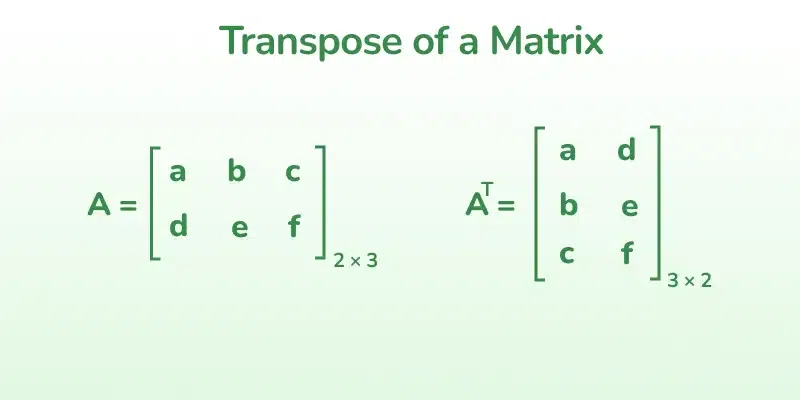

In [6]:
def matrix_display(m: int, n: int, arr_vals: list[float], T: bool = False) -> list[list[float]] | None:
    '''
    Returns a matrix in normal or transposed form

    Inputs:
        m: int - number of rows in the matrix
        n: int - number of columns in the matrix
        arr_vals: list[float] - array of matrix values
        T: bool - transpose flag, True if need to return transposed, False if need to return matrix in regular form

    Outputs:
        out: list[list[float]] - matrix in tradition row-major representaion, list of (sub)lists, where each (sub)list represents a row
    '''
    assert 1 <= m <= 1_000 and 1 <= n <= 1_000, f"m and n aren't inside of the boundaries, m:{m}, n:{n}"
    assert 1 <= m*n <= 105, f"The product of m and n is too large, m*n:{m*n}"

    try:
        out = []
        if T:
            for i in range(n):
                out.append(arr_vals[i::n])
            
        else:
            for i in range(m):
                # print(f'i:{i}, n*i:{n*i}, (i+1)*n:{(i+1)*n}')
                out.append(arr_vals[i*(n):(i+1)*n])
    
        return out

    except:
        print("Failure during computation")
        return None


#Code below is for you to check yourselves
np.random.seed(69)

for i in tqdm(range(10_000)):
    m, n = np.random.randint(2, 10, 2)
    matrix = np.round(np.random.rand(m, n), 3)
    assert np.allclose(matrix, matrix_display(m, n, matrix.flatten().tolist(), False))
    assert np.allclose(matrix.T, matrix_display(m, n, matrix.flatten().tolist(), True))

100%|██████████████████████████████████████████████████████████████████████████| 10000/10000 [00:01<00:00, 5886.60it/s]


You are given a **0-indexed** array ```nums``` of size ```n``` consisting of non-negative integers\
You need to apply ```n - 1``` operations to this array where, in the ith operation (0-indexed),\
you will apply the following on the ith element of nums:

If ```nums[i] == nums[i + 1]```, then multiply ```nums[i]``` by ```2``` and set ```nums[i + 1]``` to ```0```. Otherwise, you skip this operation\
After performing all the operations, shift all the 0's **to the end of the array**

For example, the array ```[1,0,2,0,0,1]``` after shifting all its 0's to the end, is ```[1,2,1,0,0,0]```\
Return the resulting array\
Note that the operations are applied sequentially, not all at once

Test cases:
1. ```Input: [1,2,2,1,1,0]```\
   ```Output: [1,4,2,0,0,0]```
2. ```Input: [10,0,2,2,3,13,4,4,0,1,1,2]```\
   ```Output: [10,4,3,13,8,2,2,0,0,0,0,0]```
3. ```Input: [0,1,0,0,0,1,1,2,3,4,5,5,0,1,2]```\
   ```Output: [1,2,2,3,4,10,1,2,0,0,0,0,0,0,0]```

In [15]:
def apply_alg(nums: list[int])->list[int]:
    '''
    Applies the algorithm to the list

    Inputs:
        nums: list[int] - list of non-negative integers

    Outputs:
        nums_post_alg: list[int] - the list nums after the algorithm application
    '''
    assert type(nums) == list, f"nums of wrong type, expected list, got {nums}"

    #ENTIRELY optional assert
    for element in nums:
        assert type(element) == int and element >= 0, "elements aren't positive integers" 
    
    non_zeros, zeros = [], []
    idx = 0
    n = len(nums)
    while idx < n: 
        if nums[idx] != 0 and idx != n-1 and nums[idx] == nums[idx + 1]:
            nums[idx] *= 2
            nums[idx+1] = 0
            non_zeros.append(nums[idx])
            zeros.append(nums[idx+1])
            idx += 2
        elif nums[idx] == 0:
            zeros.append(nums[idx])
            idx += 1
        else:
            non_zeros.append(nums[idx])
            idx += 1
        
    nums_post_alg = non_zeros + zeros #concatinate the arrays

    return nums_post_alg

print(f'{apply_alg([1,2,2,1,1,0])}\n{[1,4,2,0,0,0]}\n\n')
print(f'{apply_alg([10,0,2,2,3,13,4,4,0,1,1,2])}\n{[10,4,3,13,8,2,2,0,0,0,0,0]}\n\n')
print(f'{apply_alg([0,1,0,0,0,1,1,2,3,4,5,5,0,1,2])}\n{[1,2,2,3,4,10,1,2,0,0,0,0,0,0,0]}\n\n')

[1, 4, 2, 0, 0, 0]
[1, 4, 2, 0, 0, 0]


[10, 4, 3, 13, 8, 2, 2, 0, 0, 0, 0, 0]
[10, 4, 3, 13, 8, 2, 2, 0, 0, 0, 0, 0]


[1, 2, 2, 3, 4, 10, 1, 2, 0, 0, 0, 0, 0, 0, 0]
[1, 2, 2, 3, 4, 10, 1, 2, 0, 0, 0, 0, 0, 0, 0]




## Exercise 1

In this exercise you'll be completing the function to check the boundess of a sequence. Suppose you are given some generator/ iterator function ```func```, which represents the rule of generating the sequence, for example:
```python
def example_seq():
    n = 0
    x = 0
    while True:
        x = n
        yield x
        n += 1
```
The function above is the representation of a simple sequence $\large x_n = n$\
Another example is the representation of a sequence $\large x_n = n + 2n - 3n^3$
```python
def qubic_seq():
    n = 0 
    x = 0
    while True:
        x = n + 2*n + 3n**3
        yield x
        n += 1
```
Your task is to complete a function, which determines whether this sequence is bounded or not\
The mathematical formulation (as you should remember from your Calculus course) is:\
$\large \text{A sequence } \{a_n\} \text{ is bounded iff } \exists \text{ M } \in \mathbb{R}, \text{ M } \ge 0: |a_n| \le \text{ M } \forall n$\
In python we can't calculate limits easily (well we can but it's not in the course's scope), so we'll adopt a simple approach to check for boundness:\
The goal is to sample the sequence n times or while its elements decrease and if they stop decreasing w.r.t. some threshold, we consider the sequence bounded, otherwise it isn't bounded\
Let's now implement this logic

In [2]:
def logger(*args) -> None: #we define the logger function, here *args means that we accept any number of variables, BUT we don't accept keyword arguments
    '''
    Logs the variables into the file named logs.txt in the comma-separated format (a,b,c,d)
    
    Inputs: 
        *args - some values to log, expected to be lists of lists
        
    Outputs:
        None
    '''
    args = list(args) #make args from tuple to list
    with open("logs.txt", "a") as file:
        file.write(','.join(args)+'\n')

def check_bound(func: Callable | Iterator | GeneratorType, max_iter: int = 10_000, thrh: int = 9 , tol: int = 100) -> tuple[bool, float]:
    '''
    Checks the sequence represented by iterator/ generator to be bounded, returns True, bound if bounded and False, None if unbounded

    Inputs:
        func: Iterator | GeneratorType - the generator/ iterator function that outputs the sequence elements
        max_iter: int - maximum numbers we iterate over the sequence unless its elements decrease
        thrh: int - threshold, number of digits for rounding
        tol: int - of the difference stays below threshold for tol consecutive periods of time, we declare the sequence bounded

    Outputs:
        bounded: bool - boolean variable indicating boundness of a sequence, True for bounded, False for unbounded
        M: float - bounding value of the sequence

    '''
    #make sure we got the expected types of inputs
    assert callable(func) or isinstance(func, Iterator) or isinstance(func, GeneratorType),\
                                                                f"Variable func is of improper type, expected Iterator/ Generator, got {type(func)}"
    assert type(max_iter) == int and max_iter > 0,\
                                    f"max_iter of wrong type or less than 0, expected positive int, got {type(max_iter)}, {np.sign(max_iter)}"
    
    assert type(tol) == int and tol > 0, f"tol of wrong type or less than 0, expected positive int, got {np.sign(tol)}, {type(tol)}"

    assert type(thrh) == int and thrh > 0, f'thrh of wrong type or less than zero, expected positive int, fot {np.sign(thrh)}, {type(thrh)}'

    #initialize the varaibles to be later used
    x_last, x_new = -np.inf, 0
    n = 0 #number of times we tolerate increasing elements
    tol_n = 0 #iterator for tolerance
    x_hist = [] #history of increases of the sequence

    logger("----------\n\nNew session logs\n\n")
    
    #WARNING, POTENTIALLY AN INFINITE LOOP, REMEMBER TO ALWAYS IMPLEMENT THE STOPPING CONDITION
    for x in func():
        
        x_new = x
        diff = round(x_last - x_new, thrh)

        logger(x_new, x_last)

        print(f'\rdiff={diff}                      ', end='')
        
        if diff != 0:
            x_hist.append(x_new)
            n += 1
            
        elif diff == 0:
            tol_n += 1
            
        if tol_n == tol:
            return True, max(x_hist)
        
        if n == max_iter:
            return False, None

        x_last = x_new

    logger("\n----------")

To check that the function is implemented correctly, we'll use the unbounded sequence $\large x_n = n^{-cos(\pi n)n}$

In [3]:
def seq():
    x, n = 0, 0
    while True:
        x = n**(-np.cos(np.pi*n)*n)
        yield x
        n += 1

In [4]:
check_bound(seq)

diff=inf                                           

C:\Users\Tecno\AppData\Local\Temp\ipykernel_21136\2210508273.py:53: RuntimeWarning: overflow encountered in multiply
  diff = round(x_last - x_new, thrh)
C:\Users\Tecno\AppData\Local\Temp\ipykernel_21136\2498539031.py:4: RuntimeWarning: overflow encountered in scalar power
  x = n**(-np.cos(np.pi*n)*n)


(False, None)

## Exercise 2

Here your task is to implement a simulation of an american call option\
An american call option in finance is an option to buy a stock (or other underlying asset) for a fixed price (strike price) during some period until time $\large T$\
At any moment in time $\large t$ it gives you profit of $ max(S_t-K-C, 0) \text{, where }S_t \text{ is the stock price at time } t \text{, }K \text{ is the strike price and } C \text{ is the price of the call option}$\
Now suppose we have a bunch of such options with different $\large K$, but with the same $T$\
The task is to find the maximum profit we could make with this portfolio over the period of time T\
We also assume that the stock $\large S$ at each moment $\large t$ can go up ($\large S \rightarrow uS, u > 1$) with probability ```p``` and down ($\large S \rightarrow dS, d < 1$) with probability ```1-p``` starting from some value $\large S_0$ at time $\large t =0$

In [68]:
def calc_profit(Ns: list[int] | np.ndarray[np.int8], Cs: list[float] | np.ndarray[np.float16 | float], Ks: list[float] | np.ndarray[np.float16 | float],
                T: int, S0: float, u:float, d: float, p: float, seed: int = None)->float:
    '''
    Calculates the maximum profit of a portfolio of call options with different strike prices and the same time to maturity

    Inputs:
        Ns: list[int] | np.ndarray[np.int8] - the list of quantities of each call option
        Cs: list[float] | np.ndarray[np.float16 | float] - the list of prices of each call option
        Ks: list[float] | np.ndarray[np.float16 | float] - the list of the strike prices of each call option
        T: int - the time to maturity of each call option, also the number of time periods we consider
        S0: float - the initial price of the stock
        u: float - the multiplier for the stock going up
        d: float - the multiplier for the stock going down
        p: float - the probability for the stock to increase in price
        seed: int - the random seed to fix

    Outputs:
        max_profit: float - maximum profit that's possible with this portfolio

    '''
    #make sure we get the variables we expect
    assert {type(Ns), type(Cs), type(Ks)} <= {np.ndarray, list} and len(Ns) == len(Cs) == len(Ks),\
                                    "One of the arrays in Ns, Cs, Ks is of wrong type (expect list or np.ndarray) or arrays are of non-uniform length"
    assert type(T) == int, f"Variable T is of the wrong type, expected int, got {type(T)}"
    assert {type(S0), type(u), type(d), type(p)} == {float}, "One of the variables in S0, u, d, p is of wrong type, expect float"

    np.random.seed(seed) #fix random seed

    #There are many smart and efficient ways of finding the desired profit, but we'll implement the brute-force one
    #iterate over all time periods and compute the profits of each call option batch at each time, then find the maximum profit for each option

    iters = len(Ns) #get the number of call options
    profits = np.zeros((iters, T)) #create a matrix where the lines denote call options' profits and the columns are the time periods
    #simulated evolution of the stock price below, where 1 denotes stock has increased and 0 denotes that the stock has decreased in value
    S_evol = np.random.binomial(1, p, T).astype(np.float16)
    S_evol[S_evol == 1] = u
    S_evol[S_evol == 0] = d
    S_evol = np.cumprod(S_evol, axis=-1)*S0 #simulate evolution
    
    for t in range(T):
        #apply the pricing at each timestep to the vector of assets
        #finish the function for profit calculation below via the numpy function np.maximum
        profits[:, t] = np.apply_along_axis(arr=profits[:, t], func1d=lambda x, N, C, S, K: N*np.maximum(S-C-K, 0), axis=0, N=Ns,\
                                                                                            C=Cs, S=S_evol[t], K=Ks)

    #find the maximum values along the matrix rows and return the sum of these maximas
    max_profit = sum(profits.max(axis=1))
    return max_profit

In [74]:
Ns = [100, 10, 1]
Cs = [15, 20, 10]
Ks = [120, 150, 200]
T = 15
S0 = 100.0
u = 1.5
d = .5
p = .5
seed = 42
res = calc_profit(Ns, Cs, Ks, T, S0, u, d, p, seed)

3375.0

## Exercise 3

This exercise will focus on estimating the value of $\large \pi$ via the Monte-Carlo method. What is Monte-Carlo?\
Basically, it's any algorithm that achieves its result via sampling from some probability distributions\
The setup is as follows: we know that area of a square is $a^2$ and the area of a circle inside of the square is $\pi r^2$, here $a=2r$\
We're going to generate random pairs of coordinates $\large (x , y) : x$ ~ $\large U[0, 1]$, $\large y$ ~ $\large U[0, 1]$
If we generate enough then the ratio of points that belong to the circle to the points that belong to the square should be equal to the ratio of the areas:\
$$ \Large \frac{\pi r^2}{4r^2} = \frac{\pi}{4}$$
Then $\large \pi$ is just 4 times the result. Below is the visualization of this method\
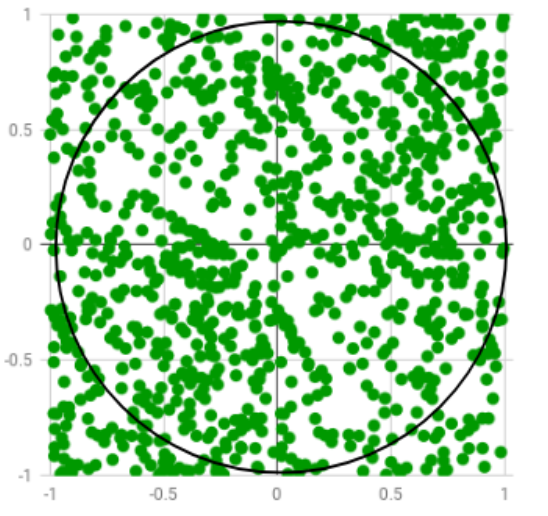

In [39]:
def find_pi(N: int)->float:
    '''
    Estimates the value of pi via the Monte-Carlo method

    Inputs:
        N: int - number of points to generate

    Outputs:
        pi_est: float - estimate of pi
    '''
    assert type(N) == int, f'N of wrong type, expected int, got {type(N)}'

    vals = np.random.uniform(-1, 1, N*2) #generate 2*N random values that are of U[0, 1] distribution
    x, y = vals[:N], vals[N:] #vals.reshape(2, -1)

    r = np.sqrt(x**2 + y**2) < 1 

    #reminder: points belong to the circle if they are less than r away from the center of it
    n_circle, n_square = x[r].shape[0] , N #np.where(r)[0].shape[0], N

    pi_est = n_circle / n_square * 4
    return pi_est

In [44]:
#for you to check yourselves

N = 10_000_000 

print(np.pi, find_pi(N)) #these should be fairly close

3.141592653589793 3.1419664


## Exercise 4

You are given a **0-indexed** 2D integer array nums. Initially, your score is 0. Perform the following operations until the matrix becomes empty:

From each row in the matrix, select the **largest** number and remove it. In the case of a tie, it does not matter which number is chosen\
Identify the highest number amongst all those removed in step 1. Add that number to your score\
Return the final score. This exercise is supposed to be done via numpy

*Note: it's not mandatory to modify the matrix, you just need to return the correct score*

In [56]:
def apply_new_alg(nums: list[list[int]]) -> int | None:
    '''
    Applies the algorithm to the matrix
    
    Inputs:
        nums: list[list[int]] - array of arrays of integer values

    Outputs:
        score: int - score
    '''
    assert type(nums) == list, "nums isn't a matrix"

    score = None

    #here the try block exists to handle errors of applying mathematical operations to non-numeric datatypes
    try:

        n_rows, n_columns = len(nums), len(nums[0])
        maxs = []
        score_current = 0
        for i in range(n_columns):
            #select the largest numbers per row
            maxs = np.max(nums, axis=1)
            #remove each largest number
            for j in range(n_rows):
                nums[j].remove(maxs[j])
            
            score_current += max(maxs)
            
    except:
        print("Error ocurred during computation, probably there were non-numeric datatypes in the matrix nums")

    else:
        score = score_current.copy()###your code here to assign the value obtained in the try block to the score variable

    finally:
        return score

In [57]:
#to check your solution

assert 15 == apply_new_alg([[7,2,1],[6,4,2],[6,5,3],[3,2,1]])

## Exercise 5

In this exercise you'll be filling missing pieces for the implementation of the gradient descent algorithm, it is defined as follows

$\large \text{For an arbitrary function f(x) that is defined and differentiable at point x*, where x is some vector of parameters then f(x) descreases}$\
$\large \text{fastest if one goes in the direction of its negated gradient at point x*:}$\
$$ \large x_{n+1} = x_{n} - \lambda \nabla f(x) $$
$\large \text{Here } x_{i} \text{ denotes the value of } x \text{ at iteration } i \text{ and } \nabla \text{ is the gradient (derivative) of } f \text{ w.r.t. } x$\
$\large \text{We apply this formula until convergence (until } x \text{ stops changing)}$

For the sake of simplicity we'll firstly take some arbitrary quadratic polynomial with the positive coefficient at its quadratic part:\
$\large f(x) = 10x^2 - 5x + 7$\
The minimum of this function is at point $\Large x = \frac{-b}{2a}=\frac{-(-5)}{2*10}=0.25$\
Our goal would be to reach this value starting from any arbitrary point $\Large x$

Your first function to fill is the function for the computation of the gradient (derivative), assume that we compute it by the following formula:

$$\large \nabla f(x) = \frac{f(x+h) - f(x-h)}{2h}$$

Here $\large h$ is some extremely small value

In [ ]:
def handle_x(x)->np.ndarray | None:
    '''
    Checks that x is a vector/ number, otherwise raises exception

    Inputs:
        x - some input x of arbitrary type

    Outputs:
        x: np.ndarray - variable x converted to the acceptable type of np.ndarray
    '''
    if type(x) not in {np.ndarray, list, float, int}: #check that x of required type
        try: #if not, try to convert it to the required type
            x = ### your code
        
        except Exception as e: #if the conversion fails (which is indicated by ValueError or TypeError), raise an error
            if type(e) in {ValueError, TypeError}: #if the exception is ValueError or TypeError we know what hapenned, so we print a message
                raise ValueError("Input x of wrong type unconvertable to standard float")
            else: #for other errors we have no clue, so we just raise them
                raise e
        else: #if all goes well, return x as a float if there's only one value in x, otherwise return it as an array
            return ###your code here
    else:
        return x
        

def comp_grad(func: Callable[list | np.ndarray | float], x: np.ndarray | list | float,
       prec: int = 9, h: float = 1e-9)->np.ndarray | float | None:
    '''
    Computes the derivative of the function func w.r.t. scalar/vector input x

    Inputs:
        func: Callable - the function to compute the derivative of 
        x: np.ndarray | list | float | int - the point (represented by a scalar/vector) near which to compute the derivative
        prec: int - precision of the output value/vector (number of digits after comma to round to)
        h: float - value of h to use

    Outputs:
        grad: np.ndarray | float - the gradient of the function f w.r.t. input x
    '''
    #make sure func variable is a function
    assert callable(func), f"The variable func is not a function, expected callable type, got {type(func)}" 

    #handle x 
    x = handle_x(x)

    #make sure other variables are also of the designated type
    assert type(prec) in {float, int} and type(h) == float, f"prec and/or h of wrong type, expected prec:int, h:float, got prec:{type(prec)}, h:{type(h)}"          

    # computation of gradient by the formula (implement via numpy arrays!)
    grad = ### your code here
    
    return grad

Now that we have our gradient computation, let's get to the main function that will be computing the neccessary point

In [ ]:
def GD(func: Callable[np.ndarray | list | float], x0: np.ndarray | list | float, lr: float = 1e-3,
      thrh: float = 1e-6, max_iter: int = 10_000, 
      prec: int = 9, h: float = 1e-9)->np.ndarray | float:

    '''
    Performs the gradient descent algorithm

    Inputs:
        func: Callable[np.ndarray | list | float] - target function for the gradient-descent algorithm
        x0: np.ndarray | list| float - the starting point for x
        lr: float - learning rate
        thrh: float - threshold, if the change in x is less than threshold then we consider that we reached the minimum of a function
        max_iter: int - maximum number of iterations (because we don't want our algorithm to run forever)
        prec: int - precision of the output value/vector (number of digits after comma to round to)
        h: float - value of h to use

    Outputs:
        x_fin: np.ndarray | float - the input x that corresponds to the minimum value of the function func
    '''
    #make sure func variable is a function
    assert callable(func), f"Variable func of wrong type, expected callable, got {type(func)}"

    #handle x
    x0 = handle_x(x0)

    x_hist = np.zeros(max_iter+1) #define the array with the history of x values
    x_hist[0] = x0 #put x0 at the starting position
    for i in range(1, max_iter+1):
        
        #compute the new x and put it in the next position in the history
        ### your code here

        print(f"\riter={i}, x={x_hist[i]}", end='')

        #if the difference between the previous x and the current x is less than threshold, then stop iterating and print that the convergence was reached
        #also assign the last non-zero value to variable x
        ### your code here
    
    return x

Time to test our function, your algorithm works as expected if the ```GD``` function returns ```0.25```

In [ ]:
quadratic_func = lambda x: 10*x**2 - 5*x + 7
x_init = 100
x_optim = GD(quadratic_func, x_init)
print(x_optim)